<a href="https://colab.research.google.com/github/neeshat/Data-Science/blob/main/Ninth_Class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Importing Necessary Libraries**

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

# **Mounting Google - Drive and Loading Dataset**

In [3]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [11]:
df_heart = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/datasets/heart.csv')

#**EDA**

In [20]:
print(df_heart.head())
print(f"\nTotal Patients: {len(df_heart)}")
print(f"Features: {df_heart.shape[1]}")
print(df_heart.info())
print(df_heart.describe().T)
print(f"\nNull:\n {df_heart.isnull().sum()}")

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Total Patients: 1025
Features: 14
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   

target
1    526
0    499
Name: count, dtype: int64


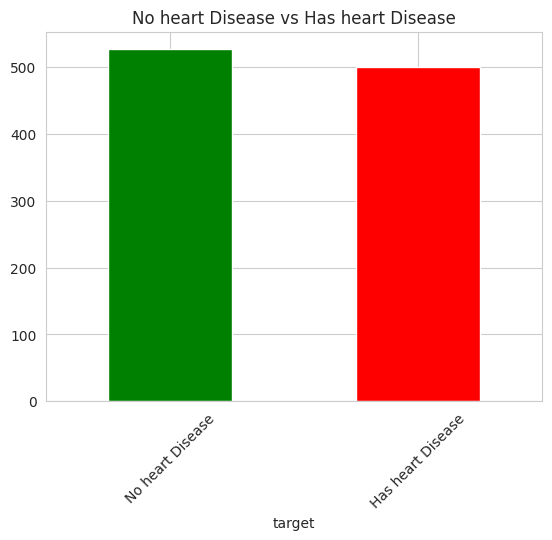

In [59]:
# Show distribution
print(df_heart['target'].value_counts())

# Plot
df_heart['target'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('No heart Disease vs Has heart Disease')
plt.xticks([0, 1], ['No heart Disease', 'Has heart Disease'], rotation=45)
plt.show()

#**Separating Features and Targets**

In [13]:
X = df_heart.drop('target', axis=1)
y = df_heart['target']

In [28]:
# Splitting into Train and Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"   Training: {X_train.shape[0]} patients ({X_train.shape[0]/len(df_heart)*100:.0f}%)")
print(f"   Testing:  {X_test.shape[0]} patients ({X_test.shape[0]/len(df_heart)*100:.0f}%)")

   Training: 820 patients (80%)
   Testing:  205 patients (20%)


In [26]:
# Standard Scaler for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#**1. Building KNN Model**

Best K: 1


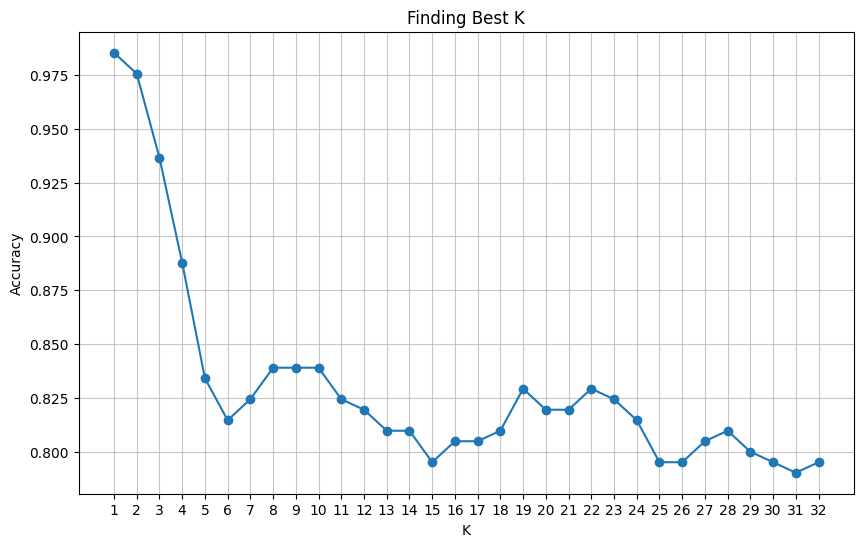

In [36]:
# Finding the Best Value of K
accuracies = []
for k in range(1, 33):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

best_k = accuracies.index(max(accuracies)) + 1
print(f"Best K: {best_k}")


# Plotting
plt.figure(figsize=(10,6))
plt.plot(range(1, 33), accuracies, marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(range(1, 33))
plt.title('Finding Best K')
plt.grid(alpha=0.7)
plt.show()

In [40]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_acc*100:.2f}%")

KNN Accuracy: 98.54%



KNN Classification Report:
                   precision    recall  f1-score   support

 No heart disease       0.97      1.00      0.99       102
Has heart disease       1.00      0.97      0.99       103

         accuracy                           0.99       205
        macro avg       0.99      0.99      0.99       205
     weighted avg       0.99      0.99      0.99       205



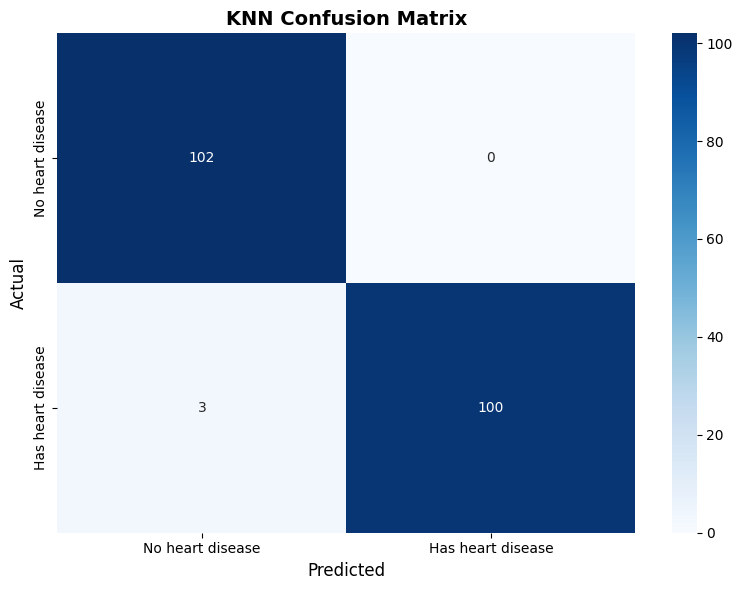

In [42]:
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn, target_names=['No heart disease', 'Has heart disease']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No heart disease', 'Has heart disease'],
            yticklabels=['No heart disease', 'Has heart disease'])
plt.title('KNN Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()


# **2. Building Decision Tree Model**

In [44]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)


Decision Tree Classification Report:
                   precision    recall  f1-score   support

 No heart disease       0.85      0.77      0.81       102
Has heart disease       0.79      0.86      0.83       103

         accuracy                           0.82       205
        macro avg       0.82      0.82      0.82       205
     weighted avg       0.82      0.82      0.82       205



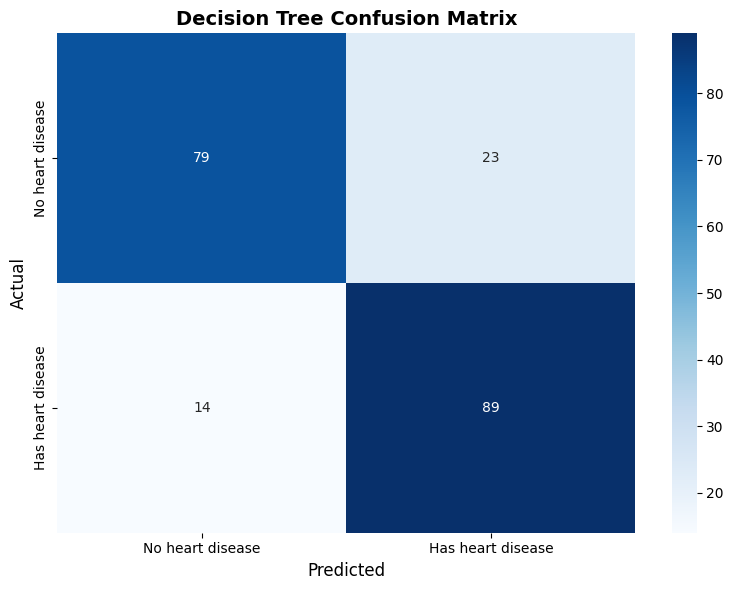

In [47]:
print("\nDecision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=['No heart disease', 'Has heart disease']))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No heart disease', 'Has heart disease'],
            yticklabels=['No heart disease', 'Has heart disease'])
plt.title('Decision Tree Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()



Feature Importance (Decision Tree):
 Feature  Importance
      cp    0.387509
    thal    0.186308
      ca    0.164022
 oldpeak    0.095632
 thalach    0.053082
     age    0.039220
trestbps    0.027873
   exang    0.026630
    chol    0.014244
 restecg    0.005480
     sex    0.000000
     fbs    0.000000
   slope    0.000000


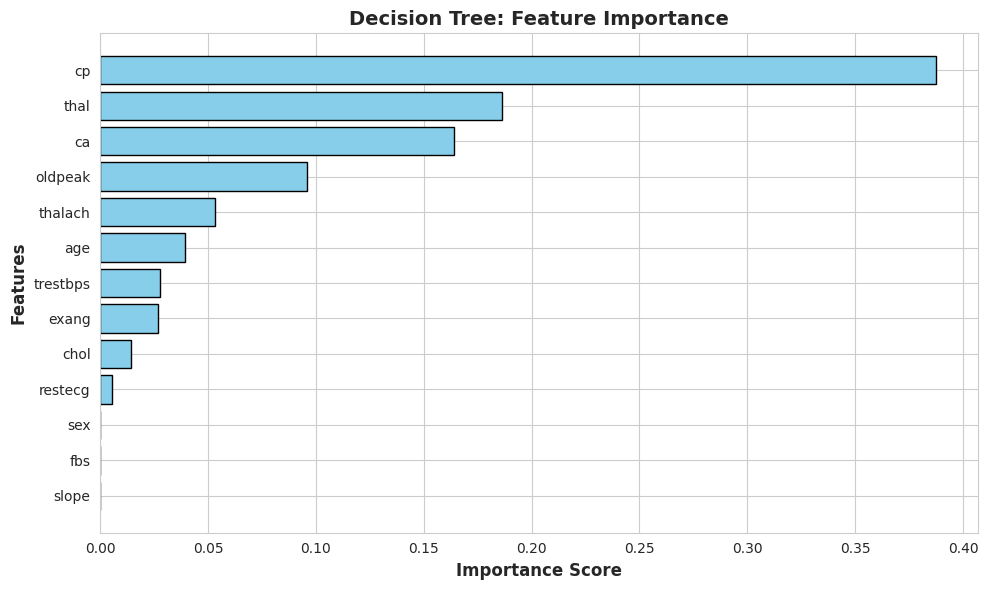

In [55]:
# Feature Importance
print("\nFeature Importance (Decision Tree):")

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'],
         color='skyblue', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Decision Tree: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()



# **3. Building Random Forest Model**

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"\n Random Forest Accuracy: {rf_accuracy*100:.2f}%")


 Random Forest Accuracy: 85.37%


\Random Forest Classification Report:
                   precision    recall  f1-score   support

 No heart disease       0.90      0.79      0.84       102
Has heart disease       0.82      0.91      0.86       103

         accuracy                           0.85       205
        macro avg       0.86      0.85      0.85       205
     weighted avg       0.86      0.85      0.85       205



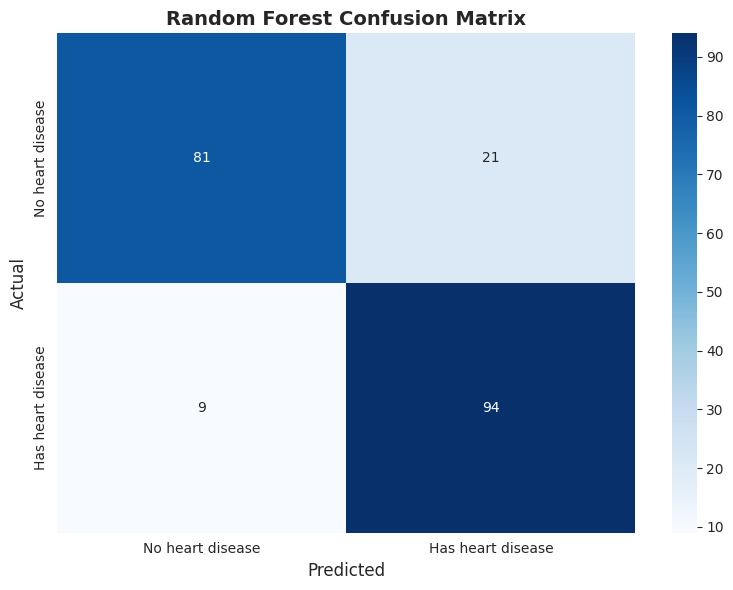

In [71]:
print("\Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No heart disease', 'Has heart disease']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No heart disease', 'Has heart disease'],
            yticklabels=['No heart disease', 'Has heart disease'])
plt.title('Random Forest Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()



Feature Importance (Random Forest):
 Feature  Importance
      cp    0.186061
      ca    0.157215
    thal    0.150984
 oldpeak    0.121967
 thalach    0.108288
   exang    0.072578
     age    0.049102
   slope    0.048800
    chol    0.034787
trestbps    0.031283
     sex    0.027631
 restecg    0.008938
     fbs    0.002366


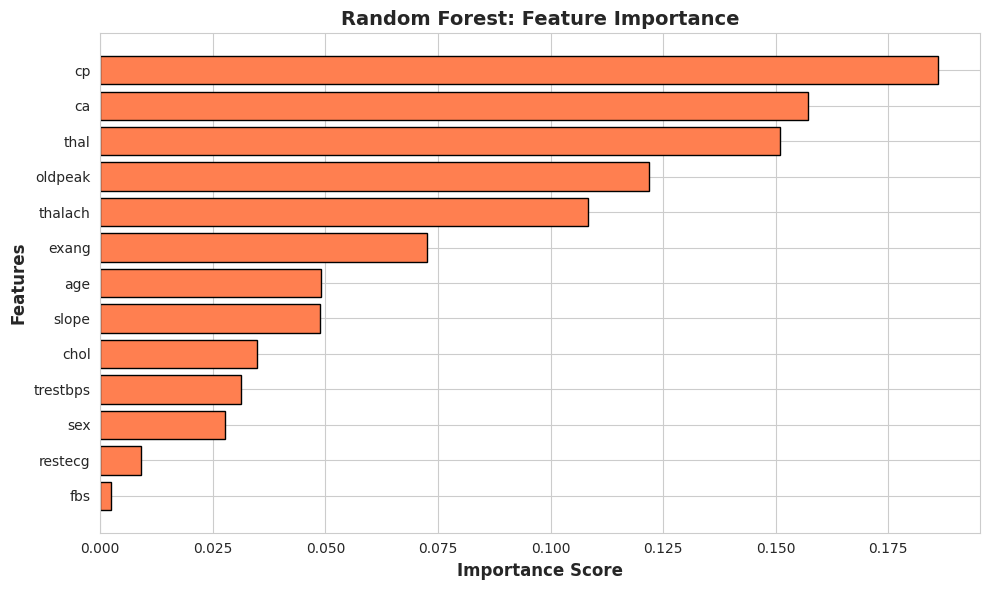

In [58]:
# Feature Importance
print("\nFeature Importance (Random Forest):")

rf_feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(rf_feature_importance.to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'],
         color='coral', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Random Forest: Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


# **Model Comparison and Final Results**

In [63]:
# Compare all models
print("\n FINAL MODEL COMPARISON")
print("=" * 60)

comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [knn_acc, dt_accuracy, rf_accuracy],
    'Accuracy %': [f"{knn_acc*100:.2f}%", f"{dt_accuracy*100:.2f}%", f"{rf_accuracy*100:.2f}%"]
})

comparison = comparison.sort_values('Accuracy', ascending=False)
print("\n" + comparison.to_string(index=False))

best_model = comparison.iloc[0]['Model']
best_acc = comparison.iloc[0]['Accuracy']

print(f"\nWINNER: {best_model}")
print(f"   Accuracy: {best_acc:.4f} {best_acc*100:.2f}%")


 FINAL MODEL COMPARISON

        Model  Accuracy Accuracy %
          KNN  0.985366     98.54%
Random Forest  0.853659     85.37%
Decision Tree  0.819512     81.95%

WINNER: KNN
   Accuracy: 0.9854 98.54%


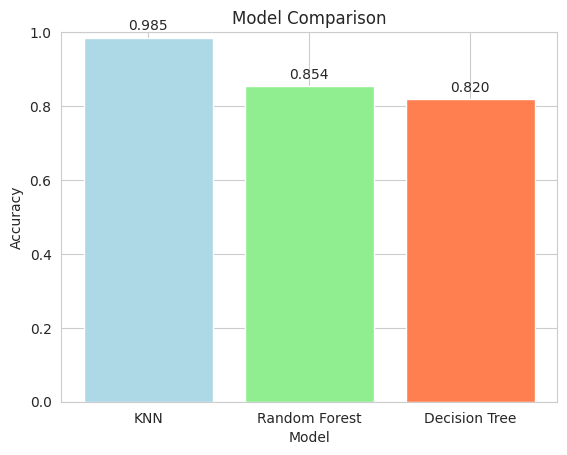

In [65]:
# Visual Comparison
plt.bar(comparison['Model'], comparison['Accuracy'], color=['lightblue', 'lightgreen', 'coral'])
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim([0, 1])

# Add values on bars
for i, acc in enumerate(comparison['Accuracy']):
    plt.text(i, acc + 0.02, f'{acc:.3f}', ha='center')

plt.show()